# Helene: Spatially-Constrained Clustering by Income (N=271)

**Objective**: Group Helene's 271 affected counties into spatially contiguous,
income-homogeneous clusters to stabilize mobility signals for downstream analysis.

**Method**: Ward's agglomerative clustering with Queen contiguity constraint,
clustering on median household income.

**Steps**:
1. Load data and build spatial weights
2. Dendrogram to identify natural cluster counts
3. Silhouette analysis for k = 10–35
4. Cluster with chosen k, check population thresholds
5. Map clusters and validate

In [84]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.sparse import lil_matrix

from libpysal.weights import Queen
from shapely.geometry import LineString

warnings.filterwarnings("ignore")

OUTPUT_DIR = "../results/helene_clustering/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load Data

In [85]:
# ── Load county list ──
with open("../results/helene/counties_geoid_cut_50.txt", "r") as f:
    helene_geoids = [int(line.strip()) for line in f if line.strip()]

# ── Load ACS ──
acs_df = pd.read_csv("acs_socioeconomic_v2.csv")
acs_df["GEOID"] = acs_df["GEOID"].astype(int)

# ── Load drop data ──
drop_df = pd.read_csv("../results/helene/largest_drop_within.csv")
drop_df["GEOID"] = drop_df["GEOID"].astype(int)

# ── Load county geometries ──
county_shp = "./../../hurricane_oct/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp"
counties_gdf = gpd.read_file(county_shp)
counties_gdf["GEOID"] = counties_gdf["GEOID"].astype(int)

# Filter and merge
gdf = counties_gdf[counties_gdf["GEOID"].isin(helene_geoids)].copy()
gdf = gdf.merge(
    acs_df[["GEOID", "total_population", "median_household_income",
            "pct_no_vehicle", "insurance_coverage_pct"]], on="GEOID", how="left"
)
gdf = gdf.merge(drop_df[["GEOID", "largest_drop"]], on="GEOID", how="left")

# Project
gdf = gdf.to_crs(epsg=5070)

# Track
track_gdf = gpd.read_file("./../../hurricane_oct/data/storm_track/helene_storm_track.shp").to_crs(epsg=5070)
if track_gdf.geometry.geom_type.iloc[0] == "Point":
    track_line = LineString(track_gdf.geometry.tolist())
else:
    track_line = track_gdf.unary_union
track_line_gdf = gpd.GeoDataFrame(geometry=[track_line], crs="EPSG:5070")

# Distance
gdf["centroid"] = gdf.geometry.centroid
gdf["dist_to_track_mi"] = gdf["centroid"].apply(lambda pt: track_line.distance(pt)) / 1000.0 / 1.60934

# Drop counties with missing income
n_before = len(gdf)
gdf = gdf.dropna(subset=["median_household_income"]).reset_index(drop=True)
print(f"Counties: {n_before} total, {len(gdf)} with income data")
print(f"Income range: ${gdf['median_household_income'].min():,.0f} – ${gdf['median_household_income'].max():,.0f}")
print(f"Population range: {gdf['total_population'].min():,.0f} – {gdf['total_population'].max():,.0f}")

Counties: 271 total, 271 with income data
Income range: $31,767 – $131,660
Population range: 1,635 – 957,977


## 2. Build Spatial Contiguity Matrix

In [86]:
# ── Queen contiguity weights ──
w_queen = Queen.from_dataframe(gdf)
print(f"Queen weights: {w_queen.n} observations")
print(f"Mean neighbors: {w_queen.mean_neighbors:.1f}")
print(f"Min neighbors: {w_queen.min_neighbors}")
print(f"Max neighbors: {w_queen.max_neighbors}")

# Check for islands
islands = [i for i, v in w_queen.neighbors.items() if len(v) == 0]
if islands:
    print(f"\nWARNING: {len(islands)} island(s):")
    for idx in islands:
        print(f"  {gdf.iloc[idx]['NAME']} (GEOID={gdf.iloc[idx]['GEOID']})")
    print("Islands will be connected to nearest neighbor for clustering.")
else:
    print("No islands detected.")

# ── Convert to scipy sparse connectivity matrix ──
n = len(gdf)
connectivity = lil_matrix((n, n), dtype=int)
for i, neighbors in w_queen.neighbors.items():
    for j in neighbors:
        connectivity[i, j] = 1
        connectivity[j, i] = 1

# Handle islands: connect to nearest county by centroid distance
if islands:
    from scipy.spatial import cKDTree
    centroids = np.array([(pt.x, pt.y) for pt in gdf["centroid"]])
    tree = cKDTree(centroids)
    for idx in islands:
        dists, neighbors = tree.query(centroids[idx], k=2)  # k=2: self + nearest
        nearest = neighbors[1]
        connectivity[idx, nearest] = 1
        connectivity[nearest, idx] = 1
        print(f"  Connected {gdf.iloc[idx]['NAME']} → {gdf.iloc[nearest]['NAME']}")

connectivity = connectivity.tocsr()
print(f"\nConnectivity matrix: {connectivity.shape}, nnz={connectivity.nnz}")

Queen weights: 271 observations
Mean neighbors: 5.3
Min neighbors: 1
Max neighbors: 10
No islands detected.

Connectivity matrix: (271, 271), nnz=1438


## 3. Load NCHS Urban-Rural Classification

In [87]:
# ── Load NCHS Urban-Rural Classification ──
nchs = pd.read_csv("../data/NCHS Urban-Rural Classification Scheme for Counties.csv", encoding='utf-8-sig')
nchs["GEOID"] = nchs["Location"].astype(int)
nchs["nchs_code"] = nchs["2023 Code"].str.extract(r"(\d)").astype(int)
nchs["nchs_label"] = nchs["2023 Code"]

gdf = gdf.merge(nchs[["GEOID", "nchs_code", "nchs_label"]], on="GEOID", how="left")

print("NCHS distribution for Helene counties:")
print(gdf["nchs_label"].value_counts().sort_index())
print(f"\nMissing NCHS: {gdf['nchs_code'].isna().sum()}")

NCHS_LABELS = {
    1: "Large central metro",
    2: "Large fringe metro",
    3: "Medium metro",
    4: "Small metro",
    5: "Micropolitan",
    6: "Noncore (rural)",
}

NCHS distribution for Helene counties:
nchs_label
1 - Large central metro      2
2 - Large fringe metro      30
3 - Medium metro            30
4 - Small metro             35
5 - Micropolitan            62
6 - Noncore                112
Name: count, dtype: int64

Missing NCHS: 0


## 4. Stratified Spatial Clustering: Within Each NCHS Code

**Guarantee**: Every cluster contains ONLY counties with the **same NCHS code**.

**Method**: For each NCHS category:
1. Extract the subset of counties
2. Build a sub-contiguity matrix (Queen) for that subset
3. Run Ward's spatial clustering on centroids with contiguity constraint
4. Number of sub-clusters ≈ n_counties / target_size

This ensures NCHS homogeneity while creating spatially contiguous clusters.

In [101]:
# ══════════════════════════════════════════
# TARGET: ~10 counties per cluster (adjust as needed)
TARGET_CLUSTER_SIZE = 30
MIN_CLUSTER_SIZE = 1  # don't split groups smaller than this
# ══════════════════════════════════════════

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.sparse import lil_matrix

cluster_id = 0  # global cluster counter
gdf["cluster"] = -1

cluster_meta = []  # track metadata

for nchs_code in sorted(gdf["nchs_code"].unique()):
    subset = gdf[gdf["nchs_code"] == nchs_code].copy()
    n = len(subset)
    nchs_name = NCHS_LABELS.get(nchs_code, f"Code {nchs_code}")
    
    if n <= MIN_CLUSTER_SIZE:
        # Too small to split — make it one cluster
        gdf.loc[subset.index, "cluster"] = cluster_id
        cluster_meta.append({
            "cluster": cluster_id,
            "nchs_code": nchs_code,
            "nchs_label": nchs_name,
            "n_counties": n,
        })
        print(f"NCHS {nchs_code} ({nchs_name}): {n} counties → 1 cluster (C{cluster_id})")
        cluster_id += 1
        continue
    
    # Determine k for this group
    k = max(1, round(n / TARGET_CLUSTER_SIZE))
    if k == 1:
        gdf.loc[subset.index, "cluster"] = cluster_id
        cluster_meta.append({
            "cluster": cluster_id,
            "nchs_code": nchs_code,
            "nchs_label": nchs_name,
            "n_counties": n,
        })
        print(f"NCHS {nchs_code} ({nchs_name}): {n} counties → 1 cluster (C{cluster_id})")
        cluster_id += 1
        continue
    
    # Build sub-contiguity matrix for this NCHS group
    idx_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(subset.index)}
    sub_conn = lil_matrix((n, n), dtype=int)
    
    for i in subset.index:
        if i in w_queen.neighbors:
            for j in w_queen.neighbors[i]:
                if j in idx_map:  # neighbor is also in this NCHS group
                    sub_conn[idx_map[i], idx_map[j]] = 1
                    sub_conn[idx_map[j], idx_map[i]] = 1
    
    sub_conn = sub_conn.tocsr()
    
    # Check connectivity — some counties in same NCHS code may not be contiguous
    # If disconnected, reduce k or skip contiguity
    from scipy.sparse.csgraph import connected_components
    n_components, comp_labels = connected_components(sub_conn, directed=False)
    
    if n_components > k:
        # More disconnected components than clusters — assign each component as a cluster
        print(f"NCHS {nchs_code} ({nchs_name}): {n} counties, {n_components} components > k={k}")
        print(f"  Using connected components as clusters instead")
        for comp in range(n_components):
            comp_mask = comp_labels == comp
            comp_indices = subset.index[comp_mask]
            gdf.loc[comp_indices, "cluster"] = cluster_id
            cluster_meta.append({
                "cluster": cluster_id,
                "nchs_code": nchs_code,
                "nchs_label": nchs_name,
                "n_counties": int(comp_mask.sum()),
            })
            cluster_id += 1
        continue
    
    # Spatial clustering on centroids within this NCHS group
    sub_centroids = np.array([(pt.x, pt.y) for pt in subset.geometry.centroid])
    scaler_sub = StandardScaler()
    sub_centroids_z = scaler_sub.fit_transform(sub_centroids)
    
    try:
        clust = AgglomerativeClustering(
            n_clusters=k,
            connectivity=sub_conn,
            linkage="ward",
        )
        sub_labels = clust.fit_predict(sub_centroids_z)
    except Exception as e:
        # Fallback: cluster without contiguity constraint
        print(f"  WARNING: Contiguity clustering failed ({e}), using unconstrained")
        clust = AgglomerativeClustering(n_clusters=k, linkage="ward")
        sub_labels = clust.fit_predict(sub_centroids_z)
    
    for sub_k in range(k):
        mask = sub_labels == sub_k
        sub_indices = subset.index[mask]
        gdf.loc[sub_indices, "cluster"] = cluster_id
        cluster_meta.append({
            "cluster": cluster_id,
            "nchs_code": nchs_code,
            "nchs_label": nchs_name,
            "n_counties": int(mask.sum()),
        })
        cluster_id += 1
    
    print(f"NCHS {nchs_code} ({nchs_name}): {n} counties → {k} clusters (C{cluster_id-k}–C{cluster_id-1})")

total_clusters = cluster_id
print(f"\nTotal clusters: {total_clusters}")
print(f"Unassigned counties: {(gdf['cluster'] == -1).sum()}")

cluster_meta_df = pd.DataFrame(cluster_meta)
display(cluster_meta_df)

NCHS 1 (Large central metro): 2 counties → 1 cluster (C0)
NCHS 2 (Large fringe metro): 30 counties → 1 cluster (C1)
NCHS 3 (Medium metro): 30 counties → 1 cluster (C2)
NCHS 4 (Small metro): 35 counties → 1 cluster (C3)
NCHS 5 (Micropolitan): 62 counties, 19 components > k=2
  Using connected components as clusters instead
NCHS 6 (Noncore (rural)): 112 counties, 15 components > k=4
  Using connected components as clusters instead

Total clusters: 38
Unassigned counties: 0


,cluster,nchs_code,nchs_label,n_counties
0,0,1,Large central metro,2
1,1,2,Large fringe metro,30
2,2,3,Medium metro,30
3,3,4,Small metro,35
4,4,5,Micropolitan,5
5,5,5,Micropolitan,2
6,6,5,Micropolitan,3
7,7,5,Micropolitan,4
8,8,5,Micropolitan,2
9,9,5,Micropolitan,7


In [102]:
# ── Cluster summary ──
acs_full = pd.read_csv("acs_socioeconomic_v2.csv")
acs_full["GEOID"] = acs_full["GEOID"].astype(int)

# Merge raw counts if not already present
for col in ["white_pop", "pop_25plus", "bachelors_plus_count"]:
    if col not in gdf.columns:
        gdf = gdf.merge(acs_full[["GEOID", col]], on="GEOID", how="left", suffixes=("", "_dup"))

cluster_summary = gdf.groupby("cluster").agg(
    n_counties=("GEOID", "count"),
    total_pop=("total_population", "sum"),
    total_white=("white_pop", "sum"),
    total_pop25=("pop_25plus", "sum"),
    total_bachelors=("bachelors_plus_count", "sum"),
    median_income=("median_household_income", "median"),
    mean_dist_to_track=("dist_to_track_mi", "mean"),
    median_pct_no_vehicle=("pct_no_vehicle", "median"),
    median_insurance=("insurance_coverage_pct", "median"),
    nchs_code=("nchs_code", "first"),  # all same within cluster
    median_drop=("largest_drop", "median"),
).round(1)

cluster_summary["cluster_pct_white"] = (cluster_summary["total_white"] / cluster_summary["total_pop"] * 100).round(1)
cluster_summary["cluster_pct_bachelors"] = (cluster_summary["total_bachelors"] / cluster_summary["total_pop25"] * 100).round(1)
cluster_summary["nchs_label"] = cluster_summary["nchs_code"].map(NCHS_LABELS)

cluster_summary = cluster_summary.sort_values(["nchs_code", "cluster"])

print(f"Cluster summary ({total_clusters} clusters, sorted by NCHS code):")
display(cluster_summary[["n_counties", "total_pop", "nchs_label", "nchs_code",
                          "median_income", "cluster_pct_white", "cluster_pct_bachelors",
                          "mean_dist_to_track", "median_drop"]])

# Verify NCHS homogeneity
nchs_check = gdf.groupby("cluster")["nchs_code"].nunique()
assert (nchs_check == 1).all(), "ERROR: Some clusters have mixed NCHS codes!"
print("\n✓ All clusters are NCHS-homogeneous")

cluster_summary.to_csv(os.path.join(OUTPUT_DIR, "cluster_summary_nchs_geo.csv"))

Cluster summary (38 clusters, sorted by NCHS code):


,n_counties,total_pop,nchs_label,nchs_code,median_income,cluster_pct_white,cluster_pct_bachelors,mean_dist_to_track,median_drop
cluster,,,,,,,,,
0,2,1489018,Large central metro,1,69079.5,65.4,38.4,45.3,-20.8
1,30,3953204,Large fringe metro,2,74746.5,58.9,35.4,42.1,-15.2
2,30,3231694,Medium metro,3,57442.5,73.6,30.4,30.4,-17.8
3,35,1792567,Small metro,4,57159.0,69.0,25.5,31.5,-13.9
4,5,203435,Micropolitan,5,48220.0,92.9,19.2,45.0,-14.6
5,2,35633,Micropolitan,5,48224.0,66.8,16.6,44.2,-21.7
6,3,113069,Micropolitan,5,64113.0,92.7,19.0,40.2,-19.6
7,4,92078,Micropolitan,5,47536.5,91.3,17.2,16.6,-16.9
8,2,93677,Micropolitan,5,48656.0,66.4,22.6,50.7,-14.6



✓ All clusters are NCHS-homogeneous


## 5. Maps

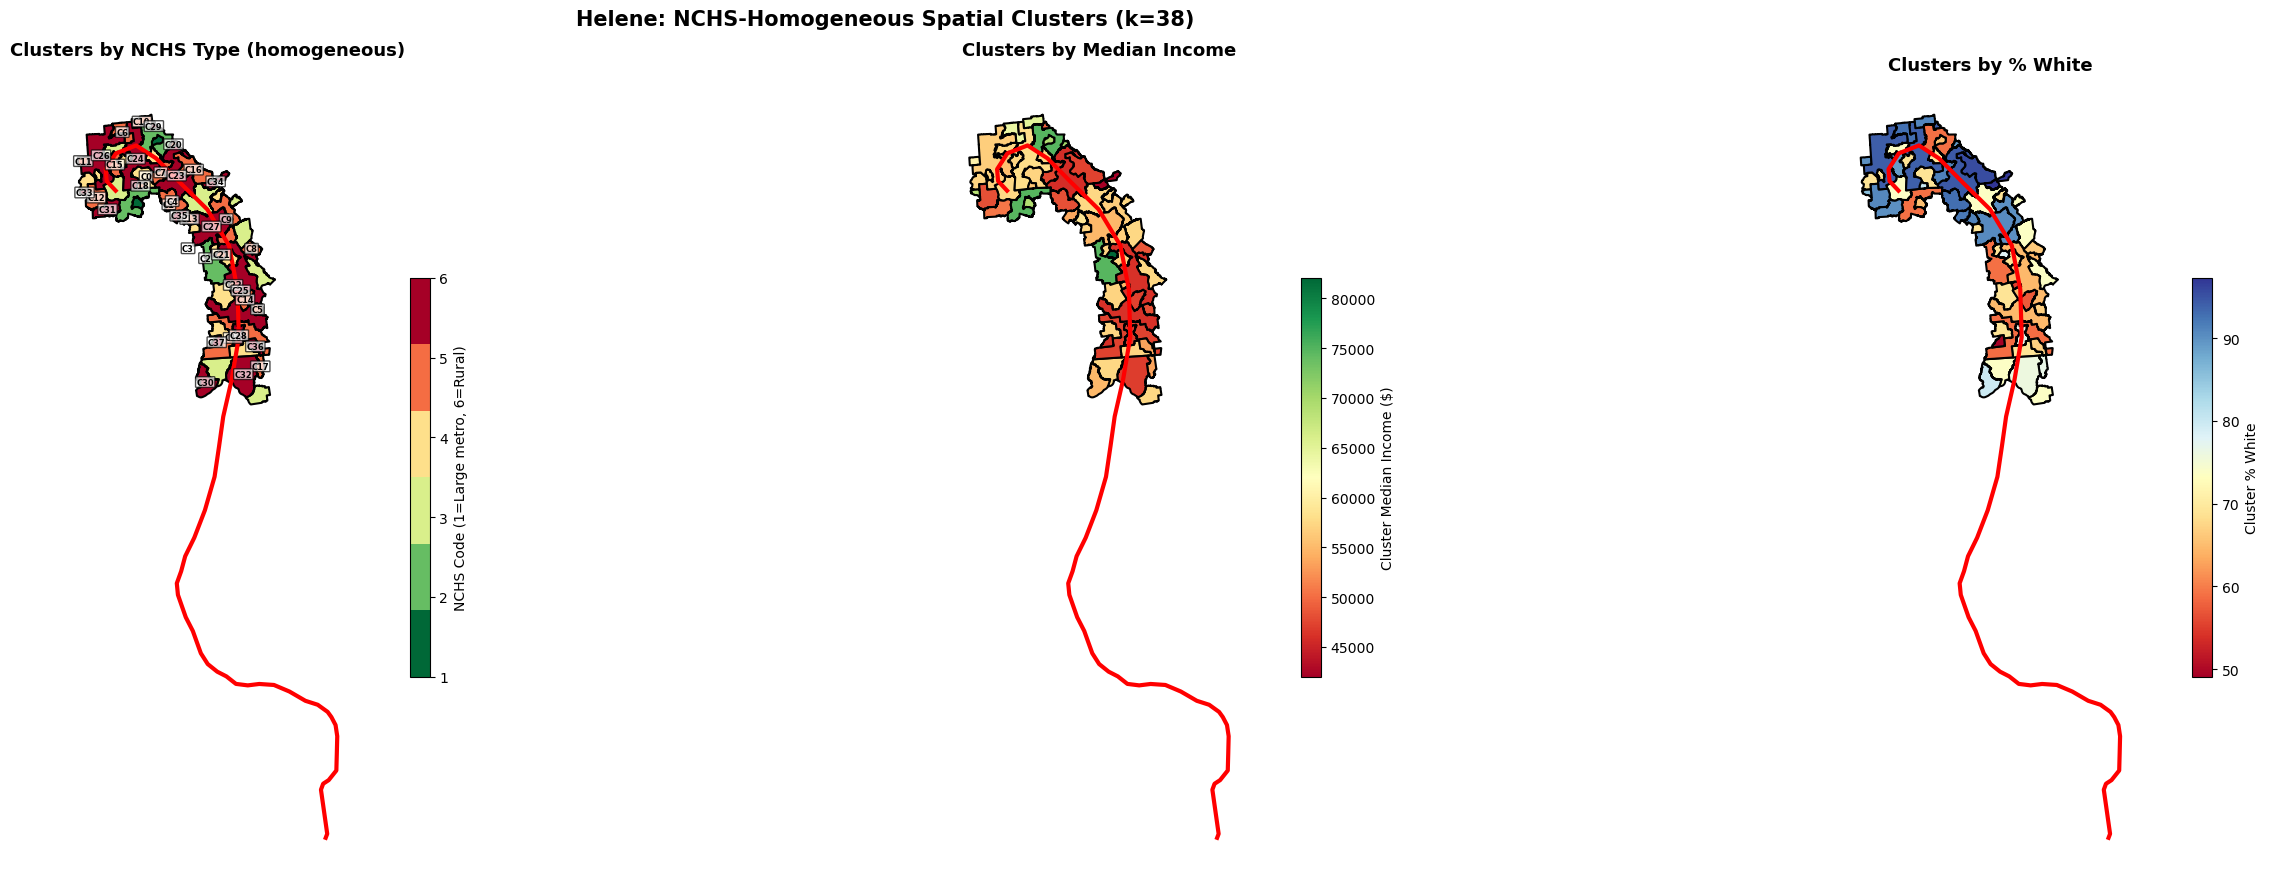

In [103]:
# ── Dissolve and map ──
numeric_cols = gdf.select_dtypes(include=[np.number]).columns.tolist()
cols_dissolve = [c for c in numeric_cols if c != "cluster"] + ["cluster", "geometry"]
gdf_dissolved = gdf[cols_dissolve].dissolve(by="cluster", aggfunc="median")

gdf_dissolved["nchs_code"] = gdf_dissolved.index.map(cluster_summary["nchs_code"])
gdf_dissolved["median_income"] = gdf_dissolved.index.map(cluster_summary["median_income"])
gdf_dissolved["cluster_pct_white"] = gdf_dissolved.index.map(cluster_summary["cluster_pct_white"])

fig, axes = plt.subplots(1, 3, figsize=(30, 9))

# Panel 1: NCHS type
cmap_nchs = plt.cm.get_cmap("RdYlGn_r", 6)
gdf_dissolved.plot(column="nchs_code", cmap=cmap_nchs, legend=True, vmin=1, vmax=6,
                    legend_kwds={"label": "NCHS Code (1=Large metro, 6=Rural)", "shrink": 0.5},
                    edgecolor="black", linewidth=1.5, ax=axes[0])
for idx, row in gdf_dissolved.iterrows():
    c = row.geometry.centroid
    n = cluster_summary.loc[idx, "n_counties"]
    axes[0].annotate(f"C{idx}", xy=(c.x, c.y), fontsize=6, ha="center", va="center",
                      fontweight="bold", bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
track_line_gdf.plot(ax=axes[0], color="red", linewidth=3)
axes[0].set_title("Clusters by NCHS Type (homogeneous)", fontsize=13, fontweight="bold")
axes[0].set_axis_off()

# Panel 2: Median income
gdf_dissolved.plot(column="median_income", cmap="RdYlGn", legend=True,
                    legend_kwds={"label": "Cluster Median Income ($)", "shrink": 0.5},
                    edgecolor="black", linewidth=1.5, ax=axes[1])
track_line_gdf.plot(ax=axes[1], color="red", linewidth=3)
axes[1].set_title("Clusters by Median Income", fontsize=13, fontweight="bold")
axes[1].set_axis_off()

# Panel 3: % White
gdf_dissolved.plot(column="cluster_pct_white", cmap="RdYlBu", legend=True,
                    legend_kwds={"label": "Cluster % White", "shrink": 0.5},
                    edgecolor="black", linewidth=1.5, ax=axes[2])
track_line_gdf.plot(ax=axes[2], color="red", linewidth=3)
axes[2].set_title("Clusters by % White", fontsize=13, fontweight="bold")
axes[2].set_axis_off()

fig.suptitle(f"Helene: NCHS-Homogeneous Spatial Clusters (k={total_clusters})",
             fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "map_nchs_homogeneous_clusters.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [104]:
# ── Export cluster assignments ──
export_df = gdf[["GEOID", "NAME", "cluster", "nchs_code", "nchs_label",
                  "median_household_income", "total_population",
                  "dist_to_track_mi", "largest_drop"]].copy()

export_df = export_df.sort_values(["cluster", "GEOID"]).reset_index(drop=True)
export_path = os.path.join(OUTPUT_DIR, "county_cluster_assignments.csv")
export_df.to_csv(export_path, index=False)
print(f"Saved: {export_path}")
print(f"{total_clusters} clusters, {len(export_df)} counties")
print(f"\nClusters per NCHS code:")
print(cluster_meta_df.groupby("nchs_code")["cluster"].count())

Saved: ../results/helene_clustering/county_cluster_assignments.csv
38 clusters, 271 counties

Clusters per NCHS code:
nchs_code
1     1
2     1
3     1
4     1
5    19
6    15
Name: cluster, dtype: int64


## 6. Next Steps

Each cluster is **NCHS-homogeneous** and **spatially contiguous**.

In `helene_cluster_recovery.ipynb`:
1. Aggregate mobility per cluster → SARIMAX → largest drop + recovery time
2. OLS regression with **nchs_code as a feature** alongside income, race, education, distance
3. Test whether the race signal persists after controlling for urban-rural type